# Example 1: Symbolic Regressor

In [1]:
import sys
import os
from pathlib import Path
# Add the parent folder (my_project) to Python's search path
sys.path.append(str(Path.cwd().parent))

%matplotlib inline
from gplearn.genetic_pmm import SymbolicRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.random import check_random_state
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import graphviz
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import math
from collections import defaultdict
import graphviz

os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

In [2]:
def get_benchmark_dataset(name, n_train=100, n_test=100, random_state=0):
    """
    Generates train and test datasets for standard Genetic Programming benchmarks.

    Parameters:
        name (str): Benchmark problem ('E1', 'E2', 'M1', 'M2', 'H1', 'H2')
        n_train (int): Number of training samples
        n_test (int): Number of testing samples
        random_state (int/RandomState): Seed for reproducibility

    Returns:
        X_train, y_train, X_test, y_test
    """
    rng = check_random_state(random_state)
    name = name.upper().replace("-", "").replace("_", "")

    def _generate_data(n_samples):

        # 1. Custom Domain Handling
        if name == 'NGUYEN7':
            # Sampling x from [0, 2] to prevent log(x + 1) domain errors (x <= -1)
            X = rng.uniform(0, 2, n_samples * 5).reshape(-1, 5)
        elif name == 'KEIJZER6':
            # Sampling positive values [1, 100] for harmonic number calculations
            X = rng.uniform(1, 100, n_samples * 5).reshape(-1, 5)
        else:
            # Default standard domain [-5, 5]
            X = rng.uniform(-5, 5, n_samples * 5).reshape(-1, 5)

        x1, x2, x3, x4, x5 = X[:, 0], X[:, 1], X[:, 2], X[:, 3], X[:, 4]

        # Define Function

        if name == 'F1':
            y = (x1 + 1) * (x2 +2) * (x3 +3) * (x4 +4) * (x5 +5)
        elif name == 'F2':
            y = (1 / (1 + x1**-4)) + (1 / (1 + x2**-4)) + (1 / (1 + x3**-4)) + (1 / (1 + x4**-4)) + (1 / (1 + x5**-4))
        elif name == 'F3':
            y = np.sin(x1) * np.sin(x1 + x1**2)
        elif name == 'F4':
            y = x1 + x2 + x3 +x4 + x5
        elif name == 'F5':
            y = x1**5 + x2**4 + x3**3 + x4**2 + x1**1

        # 2. Koza Benchmark Suite
        elif name == 'KOZA1':
            y = x1**4 + x1**3 + x1**2 + x1
        elif name == 'KOZA2':
            y = x1**5 - 2 * (x1**3) + x1
        elif name == 'KOZA3':
            y = x1**6 - 2 * (x1**4) + x1**2

        # 3. Nguyen Benchmark Suite
        elif name == 'NGUYEN1':
            y = x1**3 + x1**2 + x1
        elif name == 'NGUYEN3':
            y = x1**5 + x1**4 + x1**3 + x1**2 + x1
        elif name == 'NGUYEN5':
            y = np.sin(x1**2) * np.cos(x1) - 1
        elif name == 'NGUYEN6':
            y = np.sin(x1) * np.sin(x1 + x1**2)
        elif name == 'NGUYEN7':
            y = np.log(x1 + 1) + np.log(x1**2 + 1)
        elif name == 'NGUYEN10':
            y = np.sin(x1) + np.sin(x2**2)

        # 4. Pagie Polynomial
        elif name == 'PAGIE1':
            y = (1 / (1 + x1**-4)) + (1 / (1 + x2**-4))

        # 5. Keijzer Suite
        elif name == 'KEIJZER6':
            # Harmonic sum: sum_{i=1..x1} (1 / i)
            y = np.array([sum(1.0 / i for i in range(1, int(val) + 1)) for val in x1])

        # 6. Vladislavleva Suite
        elif name == 'VLADISLAVLEVA1':
            y = np.exp(-(x1 - 1)**2) * np.cos(x2)

        else:
            raise ValueError(f"Unknown benchmark name: '{name}'. Choose from 'E1', 'E2', 'M1', 'M2', 'H1', 'H2'.")

        return X, y

    X_train, y_train = _generate_data(n_train)
    X_test, y_test = _generate_data(n_test)

    return X_train, y_train, X_test, y_test

In [3]:
benchmarks = [
    'koza-1', 'koza-2', 'koza-3',
    # 'NGUYEN1', 'NGUYEN3', 'NGUYEN5',
    # 'NGUYEN6', 'NGUYEN7', 'NGUYEN10',
    # 'PAGIE1', 'KEIJZER6', 'VLADISLAVLEVA1',

    # 'NGUYEN10', 'PAGIE1', 'KEIJZER6', 'VLADISLAVLEVA1'
    # 'koza-3'
]

total_run = len(benchmarks)
cols = 3
rows = math.ceil(total_run / cols)

seed_number = 4;


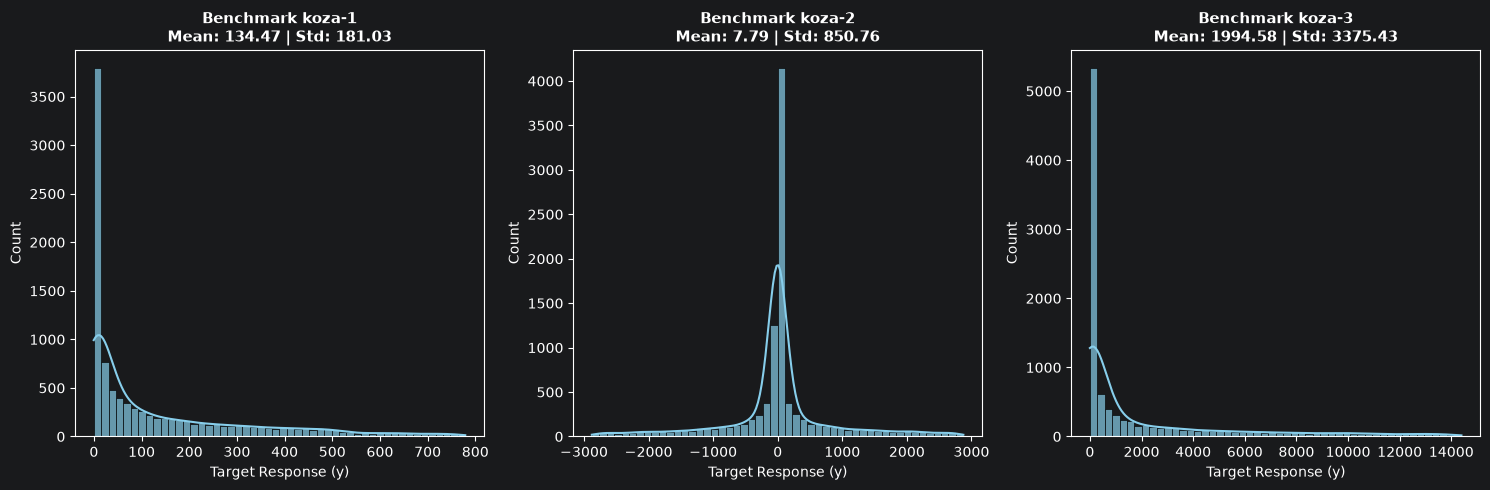

In [4]:
def plot_all_benchmarks_histogram(n_samples=10000, random_state=42, benchmarks = []):
    """
    Plots a 2x3 grid of histograms showing target distributions across all benchmark functions.
    """
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten()

    for idx, b_name in enumerate(benchmarks):
        X_tr, y_tr, _, _ = get_benchmark_dataset(b_name, n_train=n_samples, random_state=random_state)

        # Clip extreme asymptote values for H1/F16 (tan x) so outliers don't flatten the plot
        if b_name == 'H1':
            y_display = np.clip(y_tr, -100, 100)
            title_suffix = " (Clipped [-100, 100])"
        else:
            y_display = y_tr
            title_suffix = ""

        ax = axes[idx]
        sns.histplot(y_display, bins=50, kde=True, ax=ax, color='skyblue', edgecolor='black', alpha=0.7)

        # Summary stats in title
        ax.set_title(
            f"Benchmark {b_name}{title_suffix}\nMean: {np.mean(y_tr):.2f} | Std: {np.std(y_tr):.2f}",
            fontsize=11,
            fontweight='bold'
        )
        ax.set_xlabel("Target Response (y)")
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

# Run combined plotting function
plot_all_benchmarks_histogram(benchmarks=benchmarks)

In [5]:
# Training Settings

def get_params(random_seed):
    return dict(
    population_size=500,
    generations=200,
    stopping_criteria=0.01,
    tournament_size= 20,
    p_crossover=0.7,
    p_subtree_mutation=0.1,
    p_hoist_mutation=0.05,
    p_point_mutation=0.1,
    max_samples=1.0,
    verbose=1,
    parsimony_coefficient=0.01,
    random_state=random_seed,
    metric='rmse',

    prey_n_elites=1,
        predator_n_elites=1,

    predator_population_size= 50,
        catch_penalty= 1.00,
        catch_num= 2,
        catch_size= 10,

    prey_competitive_consts = 10,
        predator_competitive_consts = 10,
)

master_rng = np.random.default_rng(seed=42)
random_seeds = master_rng.integers(low=0, high=10000, size= seed_number).tolist()
print(f"Random Seeds = {random_seeds}")
# random_seeds = [0]

Random Seeds = [892, 7739, 6545, 4388]


In [6]:
results = []
trained_regressors = defaultdict(dict)

for seed in random_seeds:
    print(f"\n==================== SEED {seed} ====================")

    for name in benchmarks:
        # 1. Load dataset using the current seed
        X_train, y_train, X_test, y_test = get_benchmark_dataset(name, random_state=seed)

        # 2. Instantiate GP with current random_state
        est_gp = SymbolicRegressor(**get_params(seed))
        print(f"\n====================================================================================")
        print(f"Benchmark Running = {name}")

        # 3. Train GP
        est_gp.fit(X_train, y_train)
        print(f"Formula: {str(est_gp._program)}")


        # 4. Predict and clean numerical issues
        y_pred = est_gp.predict(X_test)
        y_pred = np.nan_to_num(y_pred, nan=0.0, posinf=1e5, neginf=-1e5)

        # 5. Calculate Test R2
        r2 = r2_score(y_test, y_pred)

        # 6. Record findings
        trained_regressors[name][seed] = est_gp
        results.append({
            'Seed': seed,
            'Benchmark': name,
            'R2_Score': r2,
            'Formula': str(est_gp._program)
        })



==================== SEED 892 ====================

Benchmark Running = koza-1
    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    28.74          22362.9       15          197.352              N/A     53.24s
   1    19.07          252.841       11          178.024              N/A      1.20m
   2    18.38          233.362       11          178.024              N/A      1.23m
   3    18.75          279.199       11          178.024              N/A      1.20m
   4    18.31          4985.87       65           153.82              N/A      1.52m
   5    17.32          307.164       65           153.82              N/A      1.21m
   6    16.61          258.717       65           153.82              N/A      1.20m
   7    16.54          252.697       65           153.82              N/A      1


--- Summary Performance across seeds ---
  Benchmark      mean       std
0    koza-1  0.998552  0.001886
1    koza-2  0.915771  0.167330
2    koza-3  0.997481  0.003083


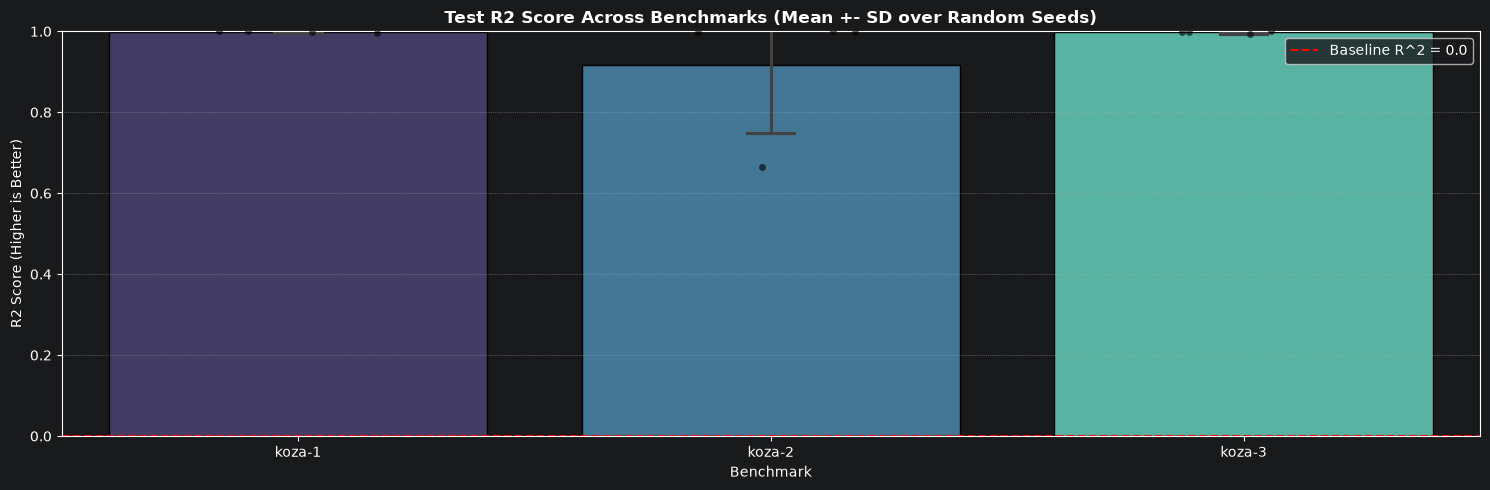

In [7]:
# Convert results into a DataFrame
df_results = pd.DataFrame(results)

# Display summary table with mean and standard deviation across seeds
df_summary = df_results.groupby('Benchmark')['R2_Score'].agg(['mean', 'std']).reset_index()
print("\n--- Summary Performance across seeds ---")
print(df_summary)

# Plot Bar Chart comparison across benchmarks with error bars (representing variability across seeds)
plt.figure(figsize=(15, 5))
sns.barplot(
    data=df_results,
    x='Benchmark',
    y='R2_Score',
    hue='Benchmark',
    palette='mako',
    errorbar='sd',       # Shows standard deviation across seeds
    capsize=0.1,         # Adds caps to error bars
    legend=False,
    edgecolor='black'
)

# Overlay individual seed points
sns.stripplot(
    data=df_results,
    x='Benchmark',
    y='R2_Score',
    color='black',
    alpha=0.6,
    jitter=0.2,
    size=5
)

plt.axhline(0, color='red', linestyle='--', label='Baseline R^2 = 0.0')
plt.ylim(top=1)
plt.title('Test R2 Score Across Benchmarks (Mean +- SD over Random Seeds)', fontsize=12, fontweight='bold')
plt.ylabel('R2 Score (Higher is Better)')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

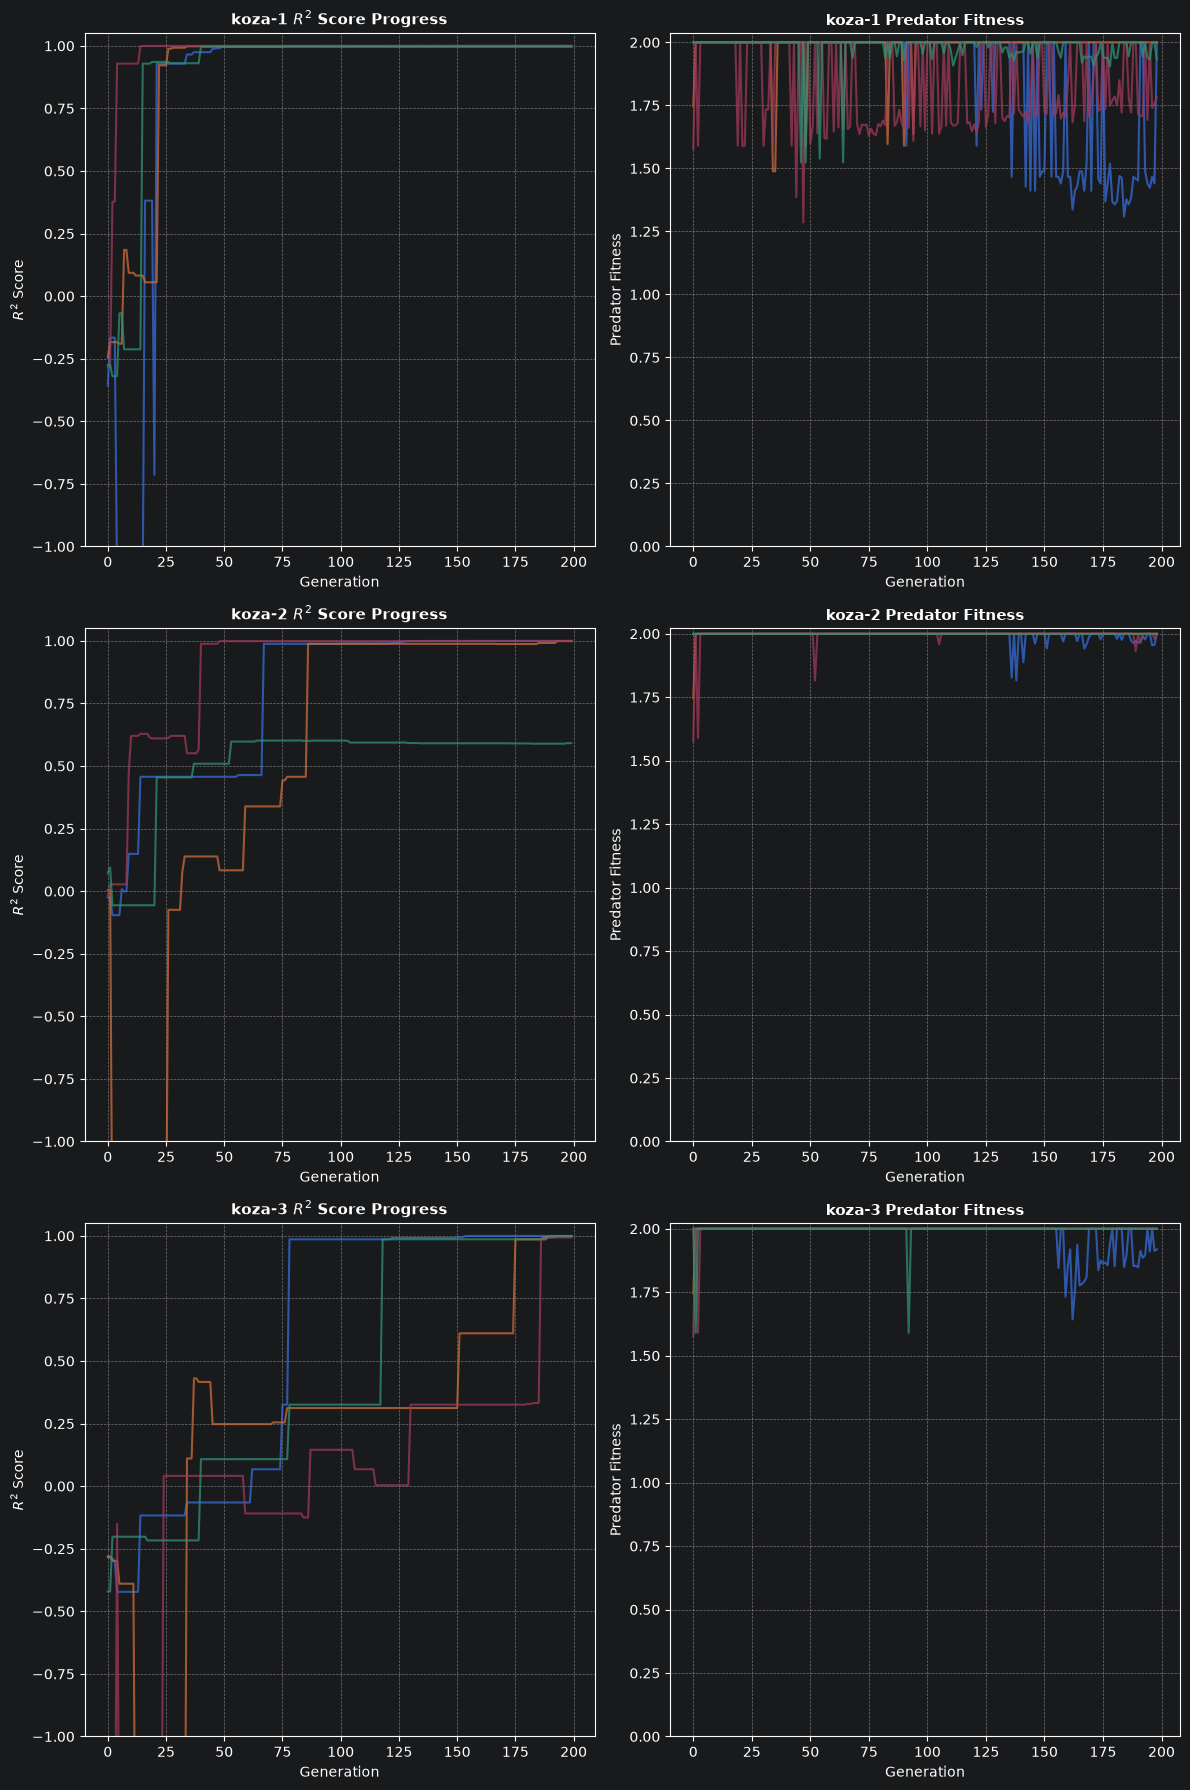

In [8]:
# Plot Fitness of Prey VS Predator

n_benchmarks = len(trained_regressors)
fig, axes = plt.subplots(n_benchmarks, 2, figsize=(12, 6 * n_benchmarks))

# Ensure axes is 2D even if there's only 1 benchmark
if n_benchmarks == 1:
    axes = axes.reshape(1, 2)

for row_idx, (name, seed_dict) in enumerate(trained_regressors.items()):
    ax_r2 = axes[row_idx, 0]
    ax_prd_fitness = axes[row_idx, 1]

    # Fetch data once per benchmark
    X_train, y_train, _, _ = get_benchmark_dataset(name, random_state=0)

    for seed, est_gp in seed_dict.items():
        # Compute R2 score progression
        r2_scores = [r2_score(y_train, program.execute(X_train)) for program in est_gp.best_programs_per_gen]

        # Plot R2 on Left Subplot
        ax_r2.plot(range(len(r2_scores)), r2_scores, linewidth=1.5, label=f'Seed {seed}', alpha=0.75)

        # Plot Distribution on Right Subplot
        predator_best_fitness = list(est_gp.predator_best_fitness)
        ax_prd_fitness.plot(range(len(predator_best_fitness)), predator_best_fitness, linewidth=1.5, label=f'Seed {seed}', alpha=0.75)

    # Formatting Left (R2 Score)
    ax_r2.set_title(f'{name} $R^2$ Score Progress', fontsize=11, fontweight='bold')
    ax_r2.set_xlabel('Generation')
    ax_r2.set_ylabel('$R^2$ Score')
    ax_r2.set_ylim(-1, 1.05)
    ax_r2.grid(True, linestyle='--', alpha=0.6)

    # Formatting Right (Distribution)
    ax_prd_fitness.set_title(f'{name} Predator Fitness', fontsize=11, fontweight='bold')
    ax_prd_fitness.set_xlabel('Generation')
    ax_prd_fitness.set_ylabel('Predator Fitness')
    ax_prd_fitness.set_ylim(bottom= 0)
    ax_prd_fitness.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

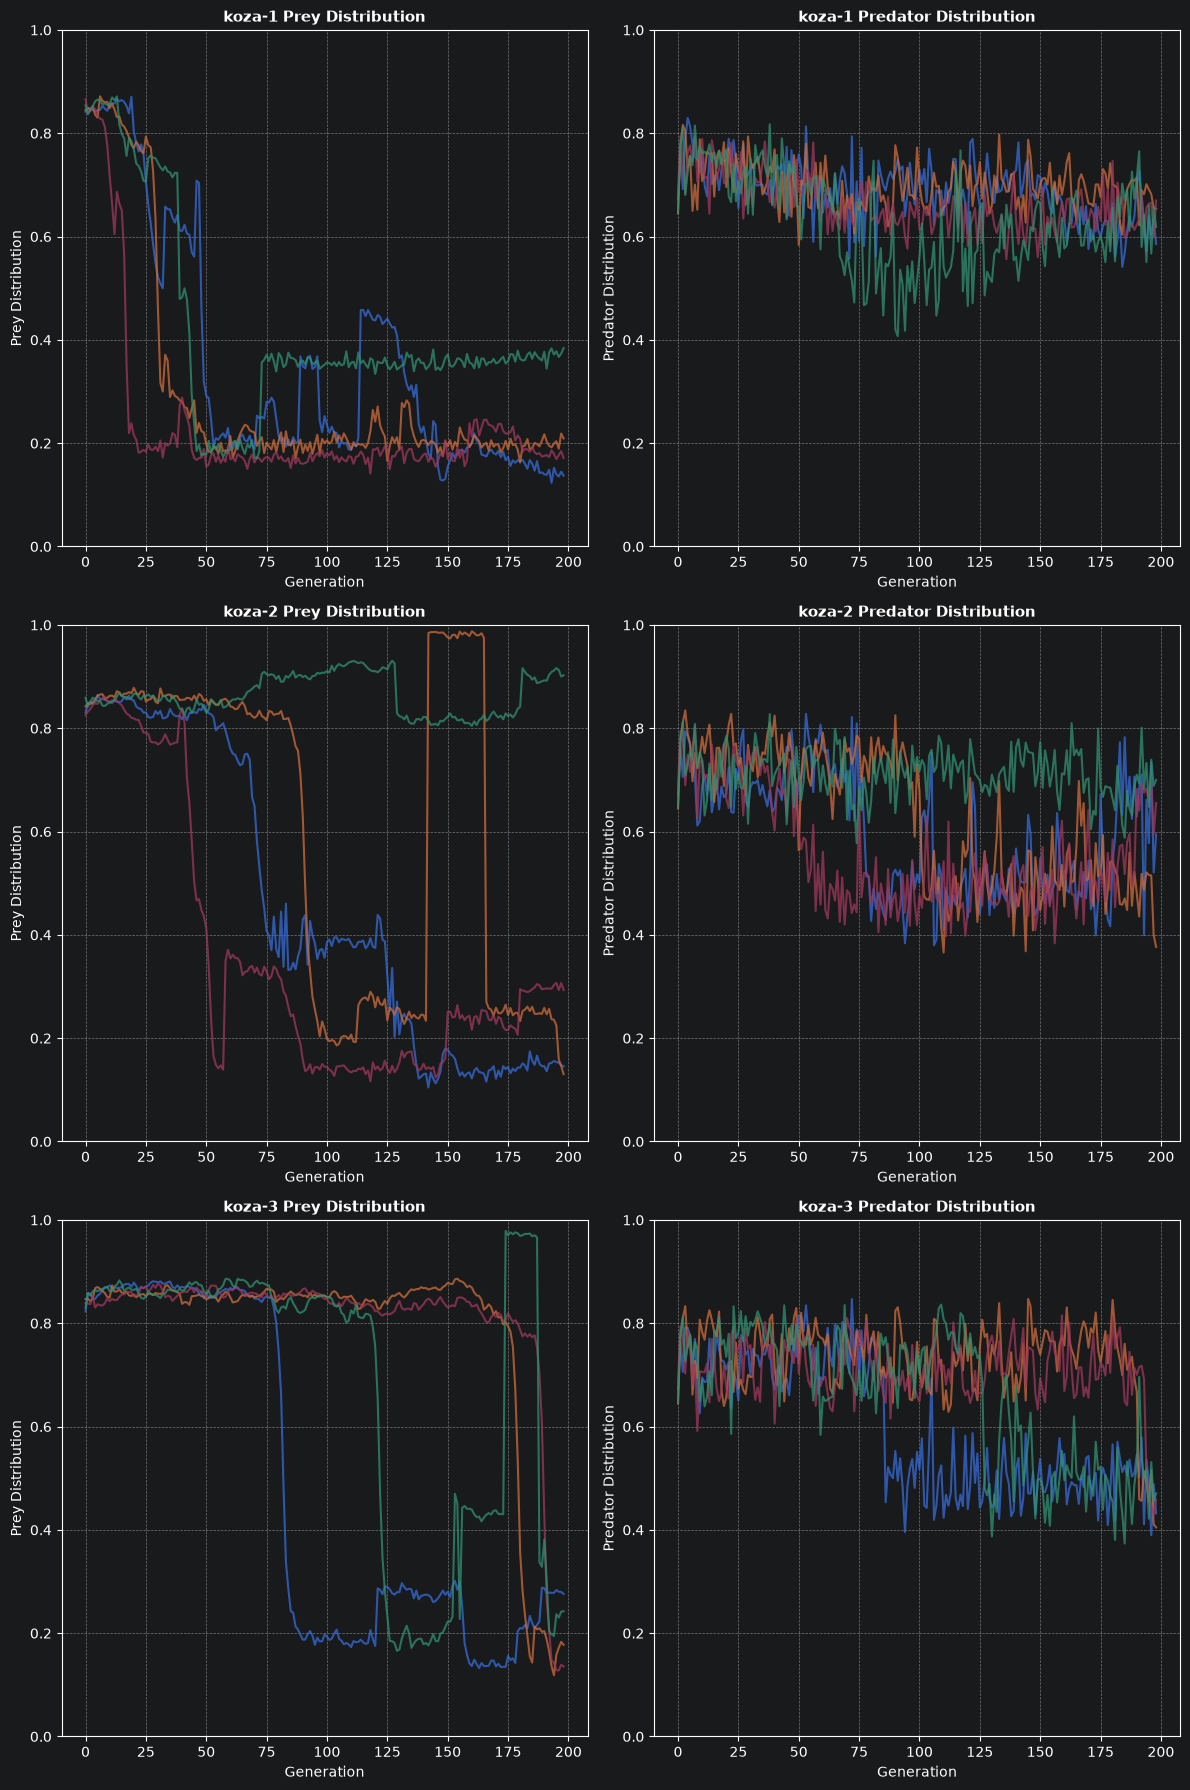

In [9]:
# Plot Distribution of Prey VS Predator


n_benchmarks = len(trained_regressors)
fig, axes = plt.subplots(n_benchmarks, 2, figsize=(12, 6 * n_benchmarks))

# Ensure axes is 2D even if there's only 1 benchmark
if n_benchmarks == 1:
    axes = axes.reshape(1, 2)

for row_idx, (name, seed_dict) in enumerate(trained_regressors.items()):
    ax_prey_dist = axes[row_idx, 0]
    ax_prd_dist = axes[row_idx, 1]

    # Fetch data once per benchmark
    X_train, y_train, _, _ = get_benchmark_dataset(name, random_state=0)

    for seed, est_gp in seed_dict.items():
        prey_dist = list(est_gp.population_distribution)
        prd_dist = list(est_gp.predator_population_distribution)

        # Plot Prey Distribution on Left Subplot
        ax_prey_dist.plot(range(len(prey_dist)), prey_dist, linewidth=1.5, label=f'Seed {seed}', alpha=0.75)

        # Plot Predator Distribution on Right Subplot
        ax_prd_dist.plot(range(len(prd_dist)), prd_dist, linewidth=1.5, label=f'Seed {seed}', alpha=0.75)

    # Formatting Left (R2 Score)
    ax_prey_dist.set_title(f'{name} Prey Distribution', fontsize=11, fontweight='bold')
    ax_prey_dist.set_xlabel('Generation')
    ax_prey_dist.set_ylabel('Prey Distribution')
    ax_prey_dist.set_ylim(0, 1)
    ax_prey_dist.grid(True, linestyle='--', alpha=0.6)

    # Formatting Right (Distribution)
    ax_prd_dist.set_title(f'{name} Predator Distribution', fontsize=11, fontweight='bold')
    ax_prd_dist.set_xlabel('Generation')
    ax_prd_dist.set_ylabel('Predator Distribution')
    ax_prd_dist.set_ylim(0, 1)
    ax_prd_dist.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()